---
title: Climatological Average using GeoCAT comp 
author: Harsha R. Hampapura
date: 2026-03-12
---

## Access CESM2 data from GDEX and compute climatology average
### Table of Contents
- [Introduction](#Introduction) 
- [Set up Dask Cluster](#Set-up-Dask-Cluster) 
- [Data Loading](#Data-Loading) 
- [Data Analysis](#Data-Analysis)  

## Introduction
- You need to install the [geocat-comp](https://geocat-comp.readthedocs.io/en/stable/) package >= v2026.03.0 to run this notebook

In [1]:
import geocat.comp as gc
import intake
import numpy as np
import pandas as pd
import xarray as xr
import re
import aiohttp
import dask 
from dask_jobqueue import PBSCluster
from dask.distributed import Client
import os

In [2]:
year0  = '1991'
year1  = '2020'
year0_str = str(year0)
year1_str = str(year1)

#Boulder coordinates
boulder_lat = 40.0150 
boulder_lon = (360-105.2705)%360
print(boulder_lat,boulder_lon)

40.015 254.7295


In [3]:
# Set up your sratch folder path
username       = os.environ["USER"]
glade_scratch  = "/glade/derecho/scratch/" + username
print(glade_scratch)
#
catalog_url = 'https://osdata.gdex.ucar.edu/d010092/catalogs/d010092-https.json' #NCAR's Object store

/glade/derecho/scratch/harshah


## Set up Dask Cluster
- Setting up a dask cluster
- Since we plan to run this noteook on  NCAR's HPC i.e, Casper, we will use a PBS Scheduler

In [4]:
# Create a PBS cluster object
cluster = PBSCluster(
    job_name = 'dask-wk26-hpc',
    cores = 1,
    memory = '8GiB',
    processes = 1,
    local_directory = glade_scratch+'/dask/spill',
    log_directory = glade_scratch + '/dask/logs/',
    resource_spec = 'select=1:ncpus=1:mem=8GB',
    queue = 'casper',
    walltime = '5:00:00',
    #interface = 'ib0'
    interface = 'ext'
)

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36319 instead
  warnings.warn(


In [5]:
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/harshah/proxy/36319/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/harshah/proxy/36319/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.101:46633,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/harshah/proxy/36319/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [6]:
n_workers =5
cluster.scale(n_workers)
client.wait_for_workers(n_workers = n_workers)
cluster

PBSCluster(ed56fd75, 'tcp://128.117.208.101:46633', workers=5, threads=5, memory=40.00 GiB)

## Data Loading
- Load CESM2 temperature data and apply geocat-comp's climatology average

In [7]:
osdf_catalog = intake.open_esm_datastore(catalog_url)
osdf_catalog

,unique
,322
variable,54
long_name,52
component,4
experiment,2
forcing_variant,2
frequency,3
vertical_levels,4
spatial_domain,3
units,21


In [8]:
osdf_catalog.df['path'].head().values

<ArrowExtensionArray>
[ 'https://osdata.gdex.ucar.edu/d010092/atm/daily/cesm2LE-historical-cmip6-FLNS.zarr',
 'https://osdata.gdex.ucar.edu/d010092/atm/daily/cesm2LE-historical-cmip6-FLNSC.zarr',
  'https://osdata.gdex.ucar.edu/d010092/atm/daily/cesm2LE-historical-cmip6-FLUT.zarr',
  'https://osdata.gdex.ucar.edu/d010092/atm/daily/cesm2LE-historical-cmip6-FSNS.zarr',
 'https://osdata.gdex.ucar.edu/d010092/atm/daily/cesm2LE-historical-cmip6-FSNSC.zarr']
Length: 5, dtype: large_string[pyarrow]

In [9]:
osdf_catalog_temp = osdf_catalog.search(variable ='TREFHT', frequency ='daily',forcing_variant='cmip6')
osdf_catalog_temp

,unique
column_0,2
variable,1
long_name,1
component,1
experiment,2
forcing_variant,1
frequency,1
vertical_levels,1
spatial_domain,1
units,1


In [10]:
%%time
dsets = osdf_catalog_temp.to_dataset_dict(xarray_open_kwargs={'engine':'zarr','backend_kwargs':{'consolidated': True,'zarr_format': 2}})


--> The keys in the returned dictionary of datasets are constructed as follows:
	'component.experiment.frequency.forcing_variant'


<div><progress max="2" value="2"></progress> 100.00% [2/2 00:08&lt;00:00]</div>

CPU times: user 502 ms, sys: 46.6 ms, total: 548 ms
Wall time: 8.09 s


In [11]:
%%time
dsets.keys()

CPU times: user 2 μs, sys: 1e+03 ns, total: 3 μs
Wall time: 5.25 μs


dict_keys(['atm.ssp370.daily.cmip6', 'atm.historical.daily.cmip6'])

In [12]:
historical_cmip6 = dsets['atm.historical.daily.cmip6']
historical_cmip6 = historical_cmip6.TREFHT
historical_cmip6

<xarray.DataArray 'TREFHT' (member_id: 50, time: 60225, lat: 192, lon: 288)> Size: 666GB
dask.array<open_dataset-TREFHT, shape=(50, 60225, 192, 288), dtype=float32, chunksize=(1, 688, 180, 270), chunktype=numpy.ndarray>
Coordinates:
  * member_id  (member_id) <U12 2kB 'r10i1181p1f1' ... 'r9i1301p1f1'
  * time       (time) object 482kB 1850-01-01 12:00:00 ... 2014-12-31 12:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
Attributes:
    cell_methods:  time: mean
    long_name:     Reference height temperature
    units:         K

## Data Analysis
#### To illustrate how the function works select small subset
- Choose data between year0 and year1
- Choose data from only one member
- Choose data for Boulder

In [13]:
%%time
historical_cmip6_30years = historical_cmip6.isel(member_id=0).sel(lat =boulder_lat,lon=boulder_lon,method='nearest').\
                             sel(time = slice(f'{year0_str}-01-01', f'{year1_str}-12-31'))
historical_cmip6_30years

CPU times: user 68.3 ms, sys: 71 μs, total: 68.4 ms
Wall time: 68.1 ms


<xarray.DataArray 'TREFHT' (time: 8760)> Size: 35kB
dask.array<getitem, shape=(8760,), dtype=float32, chunksize=(688,), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) object 70kB 1991-01-01 12:00:00 ... 2014-12-31 12:00:00
    lat        float64 8B 40.05
    lon        float64 8B 255.0
    member_id  <U12 48B 'r10i1181p1f1'
Attributes:
    cell_methods:  time: mean
    long_name:     Reference height temperature
    units:         K

CPU times: user 399 ms, sys: 49.5 ms, total: 448 ms
Wall time: 8.22 s


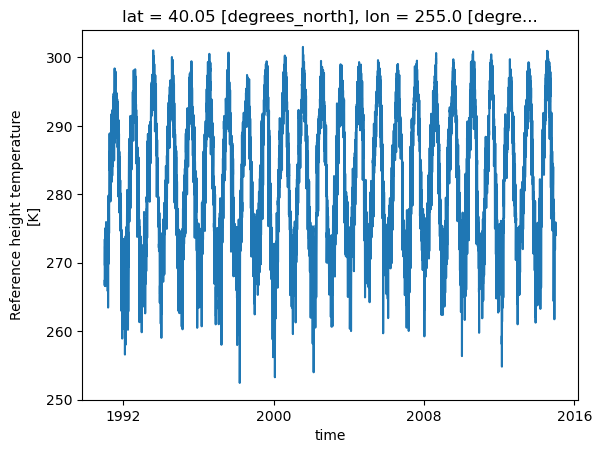

In [14]:
%%time
# Plot raw data
historical_cmip6_30years.plot()

In [15]:
# historical_cmip6_30years.values

In [16]:
%%time
hist_cmip6_monthly = gc.climatology_average(historical_cmip6_30years,freq='month')
hist_cmip6_monthly

CPU times: user 137 ms, sys: 3.34 ms, total: 141 ms
Wall time: 186 ms


<xarray.DataArray 'TREFHT' (time: 12)> Size: 48B
dask.array<groupby_nanmean, shape=(12,), dtype=float32, chunksize=(12,), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) object 96B 2002-01-16 12:00:00 ... 2002-12-16 12:00:00
    lat        float64 8B 40.05
    lon        float64 8B 255.0
    member_id  <U12 48B 'r10i1181p1f1'
Attributes:
    cell_methods:  time: mean
    long_name:     Reference height temperature
    units:         K

CPU times: user 283 ms, sys: 23.3 ms, total: 307 ms
Wall time: 5.57 s


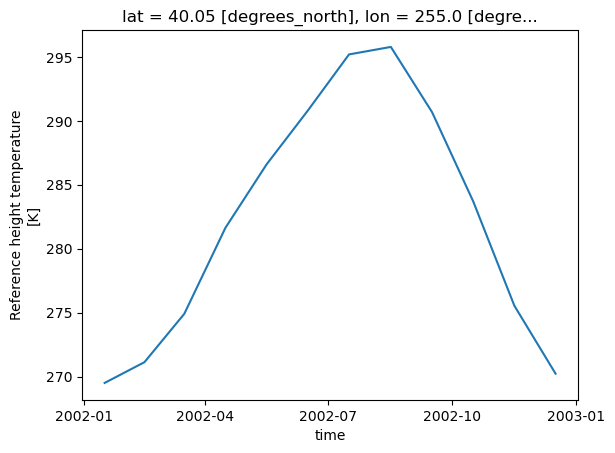

In [17]:
%%time
hist_cmip6_monthly.plot()

In [18]:
cluster.close()

<!-- cluster.close() -->